In [1]:
from tensorflow.keras.datasets import cifar10
(X_train,y_train),(X_test,y_test)=cifar10.load_data()


A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2756s 16us/step


In [2]:
(X_train.shape,y_train.shape),(X_test.shape,y_test.shape)

(((50000, 32, 32, 3), (50000, 1)), ((10000, 32, 32, 3), (10000, 1)))

In [3]:
# normalize pixels values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# reshape

X_train=X_train.reshape(-1,32,32,3)
X_test=X_test.reshape(-1,32,32,3)

In [4]:
print(X_train.min())
print(X_train.max())

0.0
1.0


In [5]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout,BatchNormalization

model=Sequential()

# first layer
model.add(Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))

# second layer
model.add(Conv2D(64,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))

# third layer
model.add(Conv2D(128,(3,3),activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.2))


model.add(Flatten())
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(10,activation='softmax'))

c:\Users\Gaurav\OneDrive\Desktop\Ai-Ml learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
# compile model
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 161,098 (629.29 KB)

 Trainable params: 160,650 (627.54 KB)

 Non-trainable params: 448 (1.75 KB)

In [7]:
#Early stopping
import tensorflow.keras.callbacks as callbacks
early_stopping =  callbacks.EarlyStopping(
    monitor='val_loss',
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=4, # how many epochs to wait before stopping
    restore_best_weights=True,
    verbose=1,
)


In [8]:
# train model with data augmentation
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

datagen.fit(X_train)

history = model.fit(
    datagen.flow(X_train, y_train, batch_size=64),
    validation_data=(X_test, y_test),
    epochs=20
)
model.save("cifar10_model.keras")

Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 32ms/step - accuracy: 0.4019 - loss: 1.6636 - val_accuracy: 0.4916 - val_loss: 1.4631
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 27s 34ms/step - accuracy: 0.5172 - loss: 1.3415 - val_accuracy: 0.5427 - val_loss: 1.2476
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 33s 43ms/step - accuracy: 0.5678 - loss: 1.2177 - val_accuracy: 0.5997 - val_loss: 1.1286
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 30ms/step - accuracy: 0.5992 - loss: 1.1358 - val_accuracy: 0.5553 - val_loss: 1.3273
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.6197 - loss: 1.0780 - val_accuracy: 0.6695 - val_loss: 0.9279
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.6349 - loss: 1.0331 - val_accuracy: 0.6323 - val_loss: 1.0495
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.6549 - loss: 0.9879 - val_accuracy: 0.6650 - val_loss: 0.9724
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 25s 32ms/step - accuracy: 0.6622 - loss: 0.9634 - 

In [10]:
(test_loss,test_accuracy)=model.evaluate(X_test,y_test)
print('Test loss: {}'.format(test_loss))
print('Test accuracy: {}'.format(test_accuracy))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7439 - loss: 0.7333
Test loss: 0.7333046793937683
Test accuracy: 0.7439000010490417


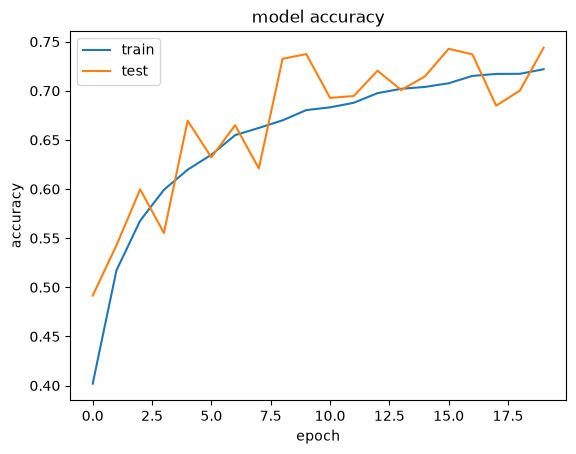

In [12]:
# summarize history from model
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'],loc='best')
plt.title('model accuracy')
plt.show()

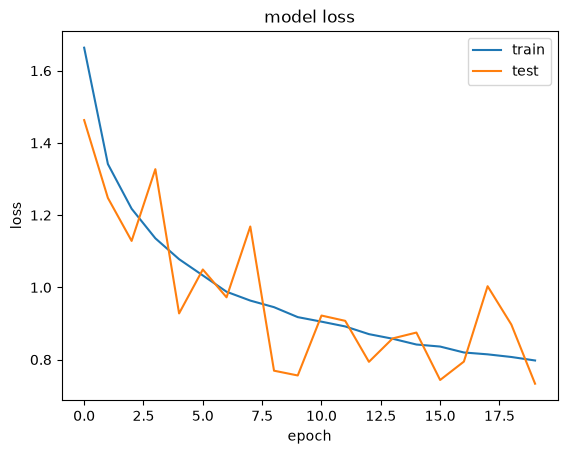

In [13]:
# summarize history loss from model
import matplotlib.pyplot as plt
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train','test'],loc='best')
plt.title('model loss')
plt.show()

In [18]:
# test on one record
import numpy as np
classNames=['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

y_pred=model.predict(X_test)
y_pred=np.argmax(y_pred,axis=1)
print("Actual:",classNames[y_test[4][0]])
print("Predicted:",classNames[y_pred[4]])


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Actual: frog
Predicted: frog


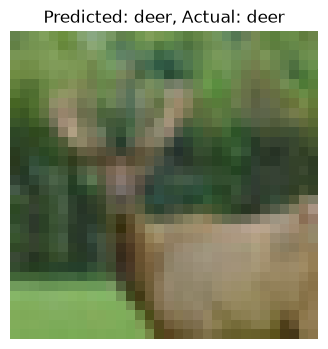

In [19]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(4,4))

plt.imshow(X_test[876])
plt.title(
    f"Predicted: {classNames[y_pred[876]]}, Actual: {classNames[y_test[876][0]]}"
)
plt.axis("off")
plt.show()

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78      1000
           1       0.90      0.89      0.89      1000
           2       0.84      0.50      0.63      1000
           3       0.67      0.51      0.58      1000
           4       0.74      0.66      0.70      1000
           5       0.68      0.67      0.67      1000
           6       0.54      0.96      0.69      1000
           7       0.77      0.83      0.80      1000
           8       0.93      0.72      0.81      1000
           9       0.82      0.89      0.85      1000

    accuracy                           0.74     10000
   macro avg       0.76      0.74      0.74     10000
weighted avg       0.76      0.74      0.74     10000



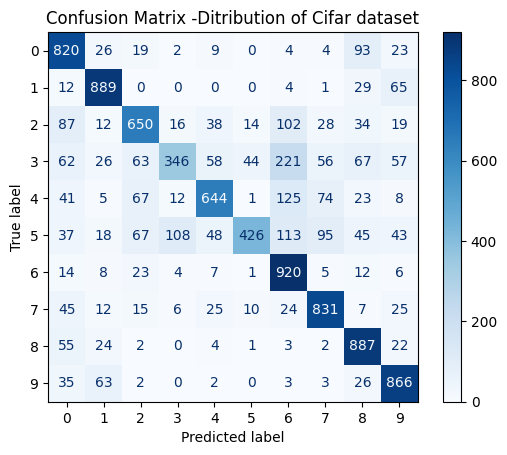

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test,y_pred,cmap="Blues")
plt.title("Confusion Matrix -Ditribution of Cifar dataset")
plt.show()